### This version of the tool is used to study the lifestyle dataset

The notebook might be a bit messy towards the end, it was mostly used to generate visualizations for the example report.

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load data
df = pd.read_csv("../lifestyle_sustainability_data_processed.csv")

df

,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,UsingPlasticProducts,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
0,35,2,800,0,1,5,2.0,100,1500,1,...,0,0,1,0,1,0,0,0,1,0
1,28,1,1500,1,1,4,1.0,250,3000,2,...,1,0,0,1,0,1,0,0,0,0
2,65,0,2500,2,0,2,0.0,400,4500,3,...,0,1,0,1,0,1,0,0,0,1
3,42,2,950,1,1,4,1.0,150,2000,1,...,0,0,1,0,1,0,0,0,0,0
4,31,1,1800,2,1,3,0.0,300,3500,2,...,1,0,0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,38,2,1789,1,1,4,2.0,150,2000,1,...,0,0,0,1,1,0,0,0,0,0
495,25,1,987,2,0,2,0.0,400,4500,3,...,0,1,1,0,0,1,0,0,0,1
496,51,3,1678,0,1,5,2.0,280,3200,2,...,1,0,0,1,0,0,1,0,0,0
497,32,0,1850,2,0,1,2.0,397,4076,1,...,1,0,0,1,1,0,0,0,0,0


### Highly experimental code, keep the amount of suspected columns to 5 or less (or prepare for a longer processing time)

**This tool combines box plots and scatterplots for detecting overlapping. Pretty neat!**

### It seems this tool is mostly useful with continuous variables. Categoricals get on top of each other, making the scatterlpots for them useless.

## NEW COMPARISON ## - MonthlyElectricityConsumption vs Rating


<Figure size 1000x600 with 0 Axes>

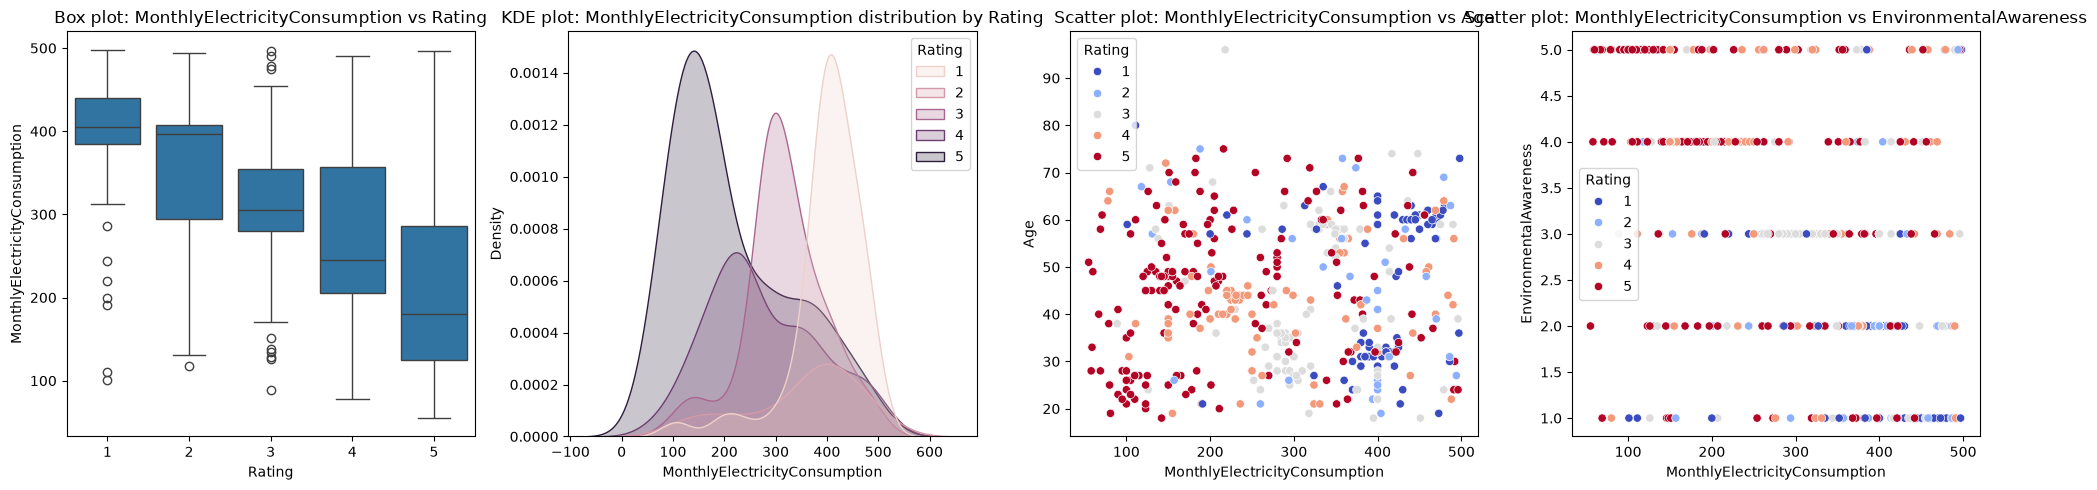

## NEW COMPARISON ## - Age vs Rating


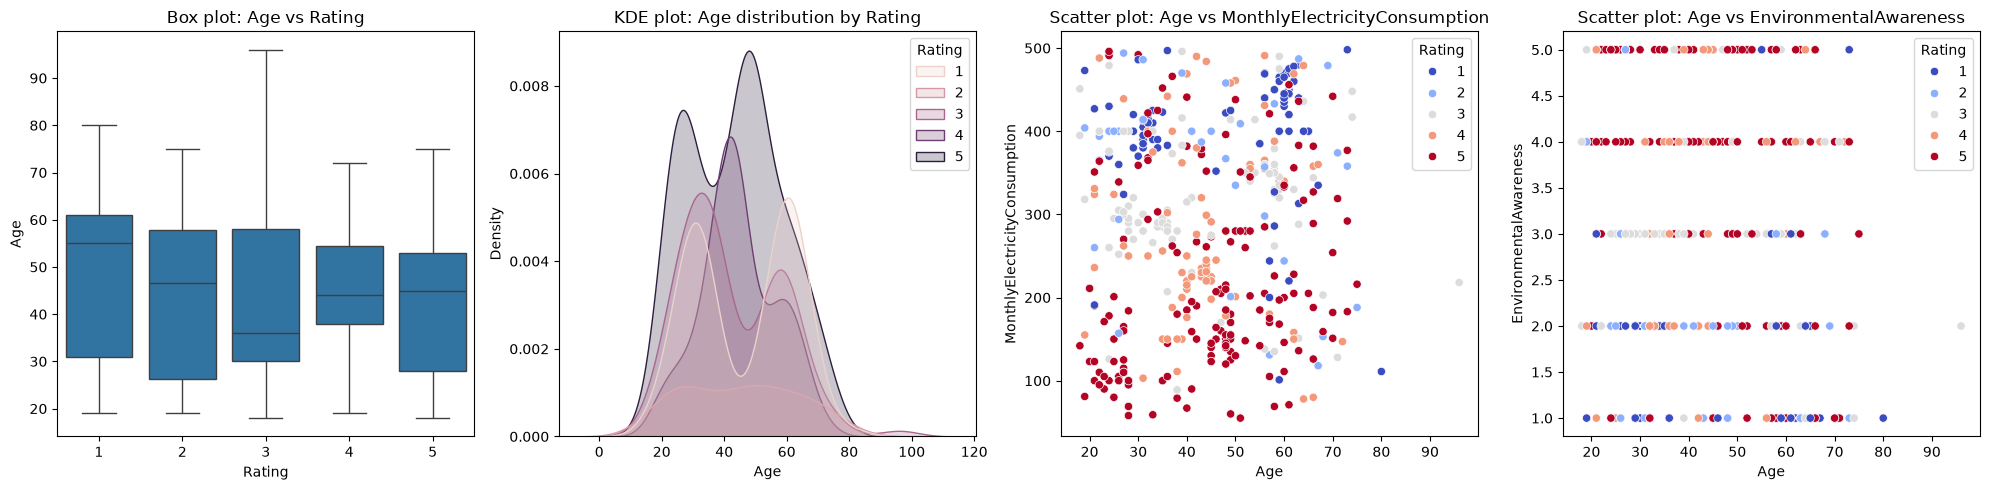

## NEW COMPARISON ## - EnvironmentalAwareness vs Rating


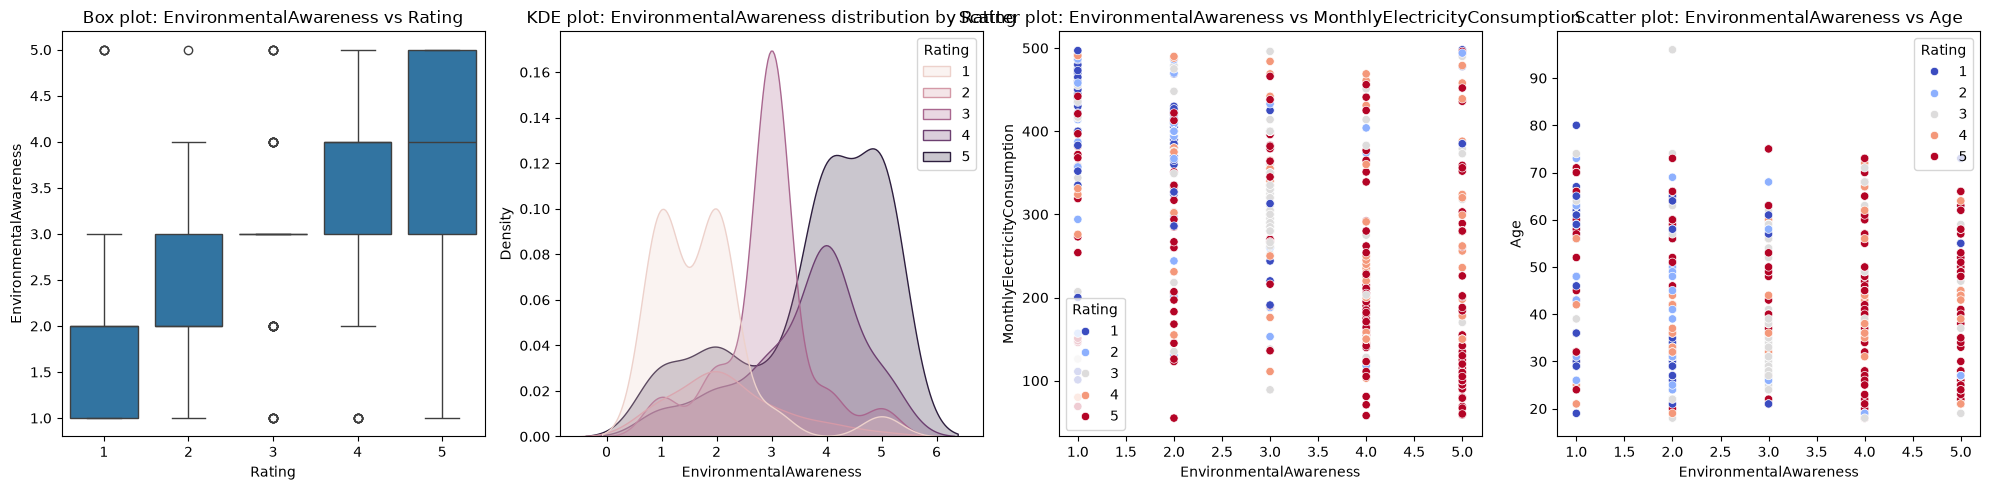

In [34]:
# CODE PARTIALLY GENERATED BY CHATGPT
# modified by instructor to have more features and small finetuning for presentation

# List of suspected columns for overlap
# USE SHAP, LIME, phik-matrix, correlation matrix etc to find columns that seems
# probable for having overlap, noise, redundancy, distribution problems and/or outlier problems
# try to keep the amount of variables to a small number at a time, so you don't slow down the
# process of plot generation below
suspected_columns = ['MonthlyElectricityConsumption', 'Age', 'EnvironmentalAwareness']
target_variable = 'Rating'  # The target variable

# Plot size settings
plt.figure(figsize=(10, 6))

# Iterate through suspected columns to generate box plots and scatter plots in a horizontal layout
for feature in suspected_columns:
    print(f"## NEW COMPARISON ## - {feature} vs {target_variable}")
    num_other_features = len([col for col in suspected_columns if col != feature])
    
    # Create a horizontal grid with 1 row and (1 + num_other_features + 1) columns
    fig, axes = plt.subplots(1, 2 + num_other_features, figsize=(5 * (2 + num_other_features), 5))
    
    # First plot: Box plot for the feature against the target variable
    sns.boxplot(x=target_variable, y=feature, data=df, ax=axes[0])
    axes[0].set_title(f'Box plot: {feature} vs {target_variable}')
    
    # Second plot: KDE plot for the feature, showing distribution by target variable
    sns.kdeplot(x=feature, hue=target_variable, data=df, fill=True, ax=axes[1])
    axes[1].set_title(f'KDE plot: {feature} distribution by {target_variable}')
    
    # Remaining plots: Scatter plots for the feature against every other feature
    for i, other_feature in enumerate([col for col in suspected_columns if col != feature]):
        sns.scatterplot(x=feature, palette="coolwarm", y=other_feature, hue=target_variable, data=df, ax=axes[i + 2])
        axes[i + 2].set_title(f'Scatter plot: {feature} vs {other_feature}')
    
    # Display the entire row of plots
    plt.tight_layout()
    plt.show()

### We will also study Yellowbrick on one of the lectures (since it offers other visualization tools for the same purposes!)

# From this section onward - experimentation with visualizations

Some parts done with ChatGPT + heavy modifications

Let's use seaborn for overlap detection...

<Axes: xlabel='DietType_Mostly Animal-Based', ylabel='EnvironmentalAwareness'>

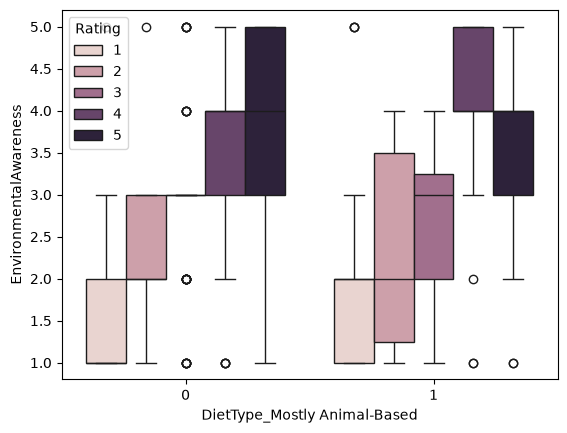

In [35]:
sns.boxplot(x="DietType_Mostly Animal-Based", y="EnvironmentalAwareness", data=df, hue="Rating")

<Axes: xlabel='DietType_Balanced', ylabel='MonthlyElectricityConsumption'>

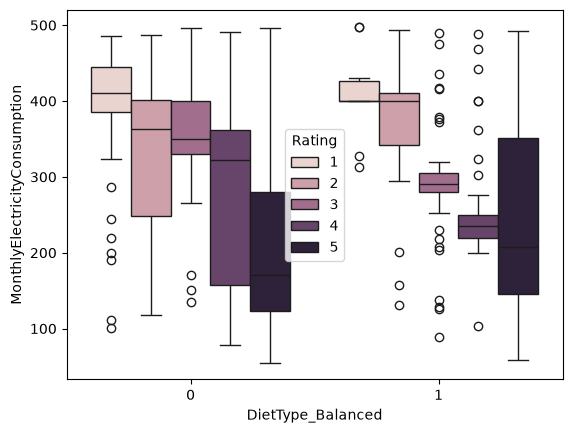

In [36]:
sns.boxplot(x="DietType_Balanced", y="MonthlyElectricityConsumption", data=df, hue="Rating")

In [37]:
# reload the data in original format
df = pd.read_csv("../lifestyle_sustainability_data.csv")


<Axes: xlabel='Rating', ylabel='EnvironmentalAwareness'>

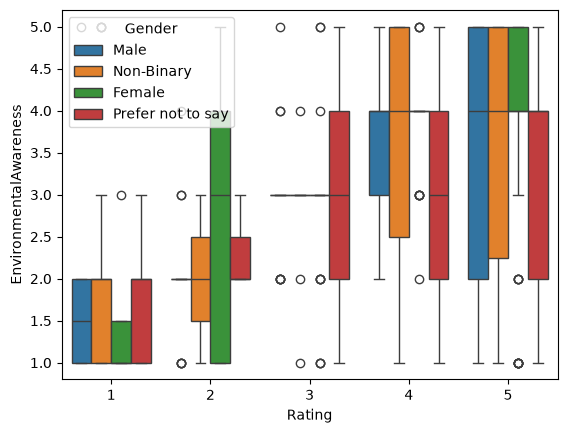

In [38]:
sns.boxplot(x="Rating", y="EnvironmentalAwareness", data=df, hue="Gender")

<Axes: xlabel='Rating', ylabel='EnvironmentalAwareness'>

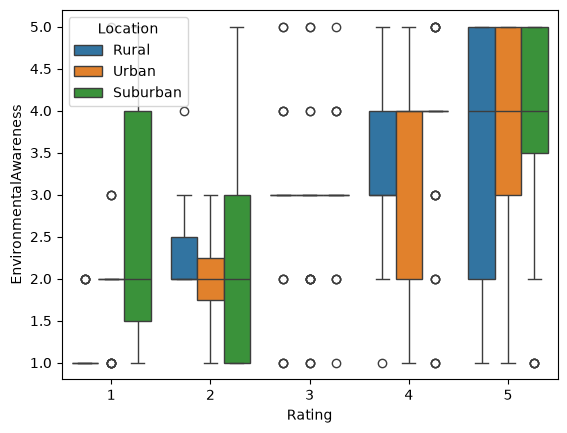

In [39]:
sns.boxplot(x="Rating", y="EnvironmentalAwareness", data=df, hue="Location")


<Axes: xlabel='Rating', ylabel='EnvironmentalAwareness'>

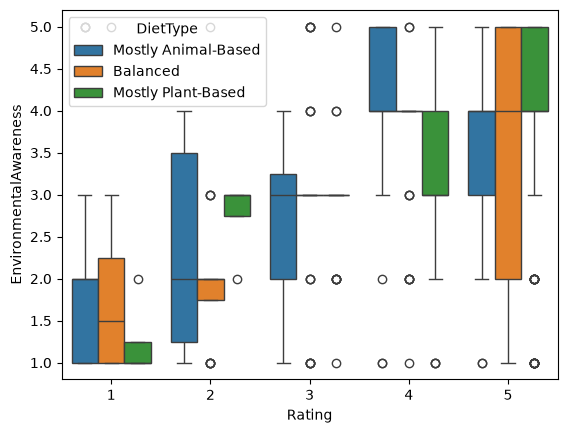

In [40]:
sns.boxplot(x="Rating", y="EnvironmentalAwareness", data=df, hue="DietType")


<Axes: xlabel='Rating', ylabel='MonthlyElectricityConsumption'>

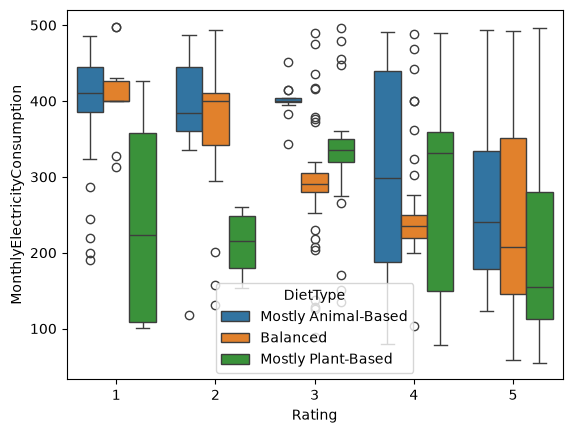

In [41]:
sns.boxplot(x="Rating", y="MonthlyElectricityConsumption", data=df, hue="DietType")

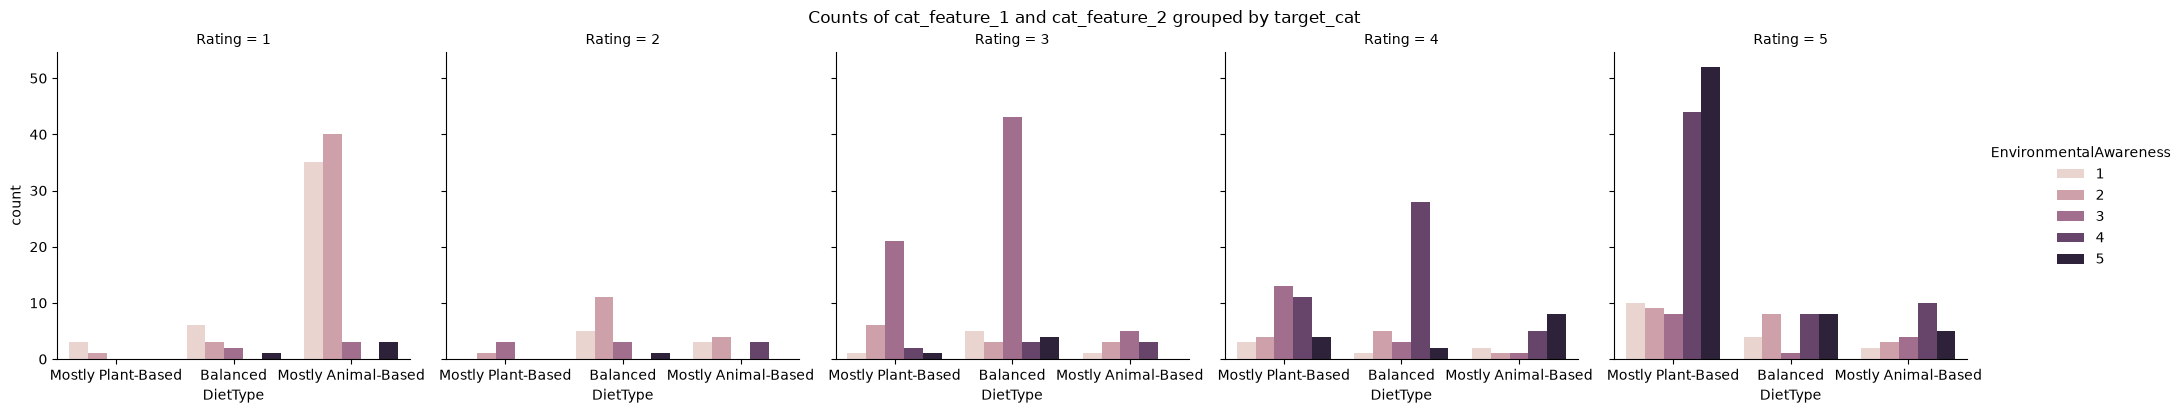

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame columns: 'cat_feature_1', 'cat_feature_2', 'target_cat'

# Count plot, split by target category using 'col' (faceting)
sns.catplot(
    data=df,
    x='DietType',
    hue='EnvironmentalAwareness',
    col='Rating',      # one subplot per target class
    kind='count',
    height=4,
    aspect=1
)

plt.suptitle("Counts of cat_feature_1 and cat_feature_2 grouped by target_cat", y=1.02)
plt.show()


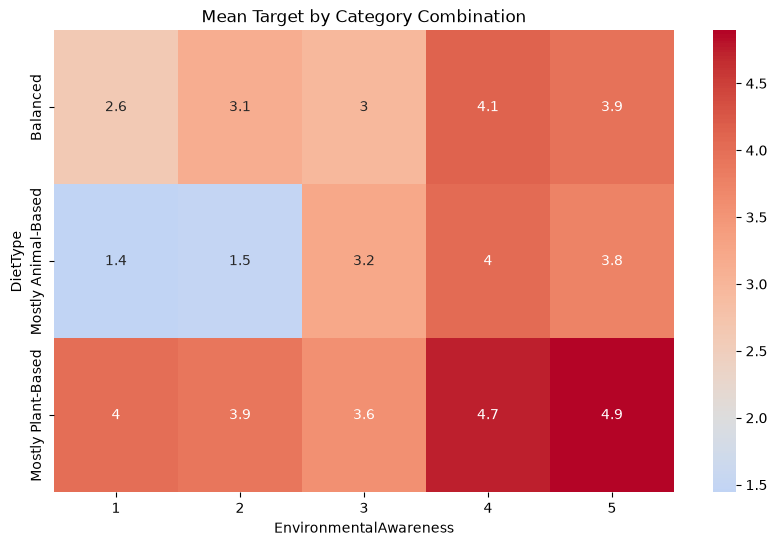

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# reload the data in original format
df = pd.read_csv("../lifestyle_sustainability_data.csv")


# Example: df has columns 'cat1', 'cat2', 'target'
pivot = df.pivot_table(index='DietType', columns='EnvironmentalAwareness', values='Rating', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='coolwarm', center=2)  # center on mid-point of 0-4
plt.title('Mean Target by Category Combination')
plt.show()


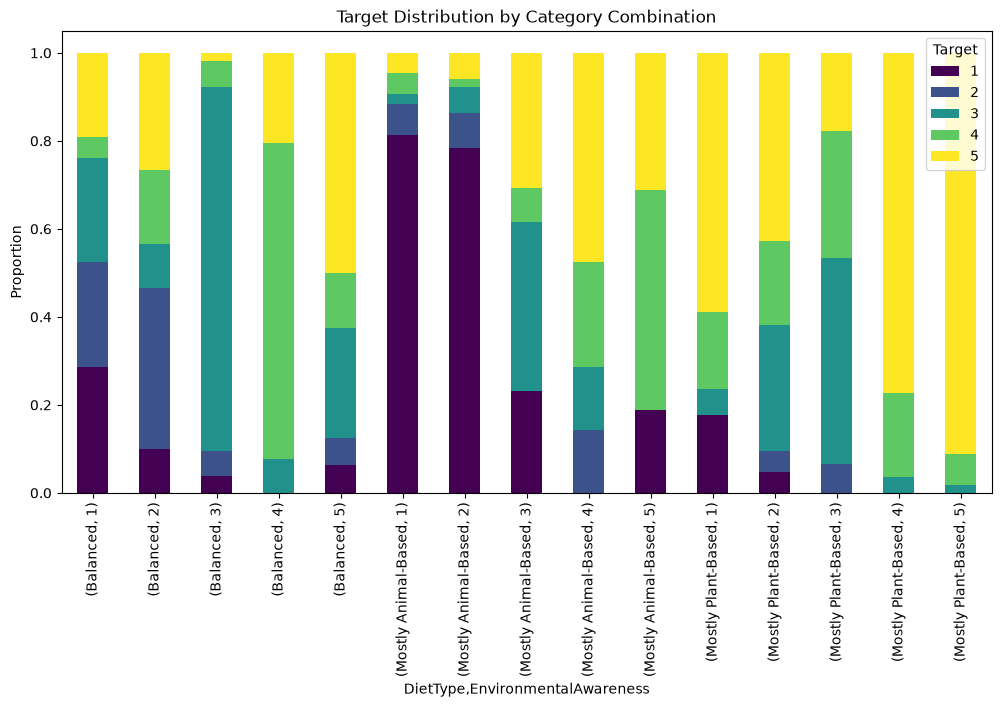

In [44]:
# Optionally group by two categorical variables
group = df.groupby(['DietType', 'EnvironmentalAwareness'])['Rating'].value_counts(normalize=True).unstack().fillna(0)

# Plot
group.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.ylabel('Proportion')
plt.title('Target Distribution by Category Combination')
plt.legend(title='Target')
plt.show()


<Axes: xlabel='Rating', ylabel='MonthlyElectricityConsumption'>

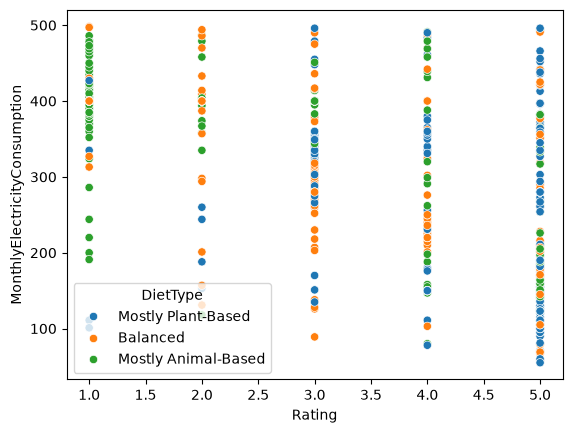

In [45]:
sns.scatterplot(x="Rating", y="MonthlyElectricityConsumption", hue="DietType", data=df)

<Axes: xlabel='Rating', ylabel='MonthlyElectricityConsumption'>

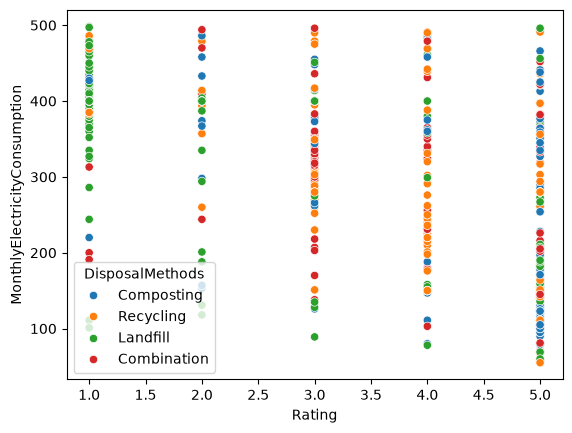

In [48]:
sns.scatterplot(x="Rating", y="MonthlyElectricityConsumption", hue="DisposalMethods", data=df)


<Axes: xlabel='Rating', ylabel='MonthlyElectricityConsumption'>

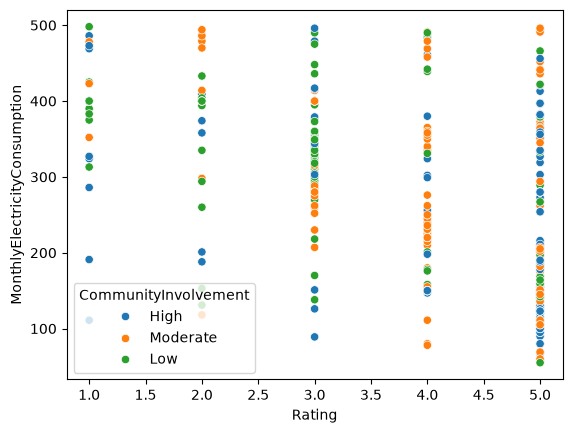

In [49]:
sns.scatterplot(x="Rating", y="MonthlyElectricityConsumption", hue="CommunityInvolvement", data=df)
